# Assignment 3

You only need to write one line of code for each question. When answering questions that ask you to identify or interpret something, the length of your response doesn’t matter. For example, if the answer is just ‘yes,’ ‘no,’ or a number, you can just give that answer without adding anything else.

We will go through comparable code and concepts in the live learning session. If you run into trouble, start by using the help `help()` function in Python, to get information about the datasets and function in question. The internet is also a great resource when coding (though note that **no outside searches are required by the assignment!**). If you do incorporate code from the internet, please cite the source within your code (providing a URL is sufficient).

Please bring questions that you cannot work out on your own to office hours, work periods or share with your peers on Slack. We will work with you through the issue.

### Clustering and Resampling

Let's set up our workspace and use the **Iris dataset** from `scikit-learn`. This dataset is a classic dataset in machine learning and statistics, widely used for clustering tasks. It consists of many samples of iris flowers. Here are the key features and characteristics of the dataset:

##### Features:
1. **Sepal Length**: The length of the sepal in centimeters.
2. **Sepal Width**: The width of the sepal in centimeters.
3. **Petal Length**: The length of the petal in centimeters.
4. **Petal Width**: The width of the petal in centimeters.

In [3]:
# Import standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Added to address warning when running k-means
import os
os.environ["OMP_NUM_THREADS"] = "1"


#### **Question 1:** 
#### Data inspection

#### Load the Iris dataset:

Use scikit-learn to load the Iris dataset and convert it into a Pandas DataFrame.
Display the first few rows of the dataset. How many observations (rows) and features (columns) does the dataset contain?

In [4]:
from sklearn.datasets import load_iris
# Load the Iris dataset
iris_data = load_iris()

# Convert to DataFrame
iris_df = pd.DataFrame(iris_data.data, columns=iris_data.feature_names)

# Display the DataFrame
#print(iris_df)

#Print the first 3 rows of the dataset 
first_5 = iris_df.head(5)
print(first_5)

# Determine the number of rows and columns
rows = len(iris_df)
columns = len(iris_df.columns)

print(f"There are " + str(rows) + " rows and there are " + str(columns) + " columns.")



   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
There are 150 rows and there are 4 columns.


#### **Question 2:** 
#### Data-visualization

Let's create plots to visualize the relationships between the features (sepal length, sepal width, petal length, petal width).


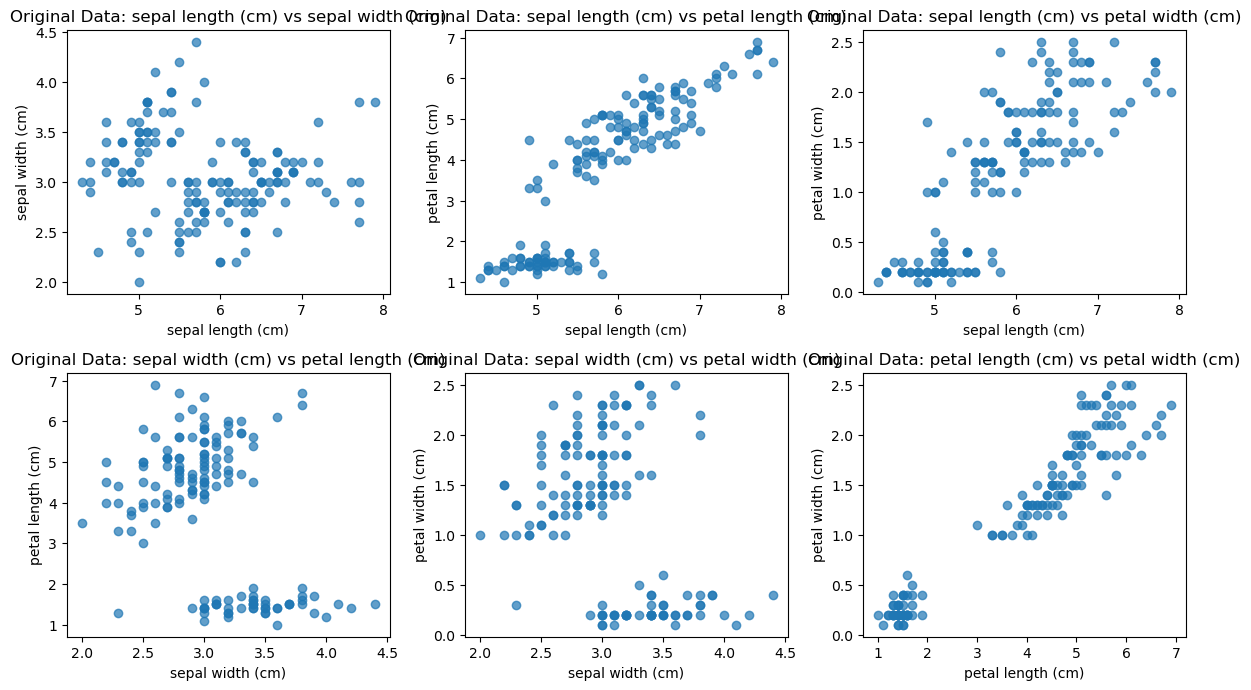

In [5]:
def plot_feature_pairs(data, feature_names, color_labels=None, title_prefix=''):
    """
    Helper function to create scatter plots for all possible pairs of features.
    
    Parameters:
    - data: DataFrame containing the features to be plotted.
    - feature_names: List of feature names to be used in plotting.
    - color_labels: Optional. Cluster or class labels to color the scatter plots.
    - title_prefix: Optional. Prefix for plot titles to distinguish between different sets of plots.
    """
    # Create a figure for the scatter plots
    plt.figure(figsize=(12, 10))
    
    # Counter for subplot index
    plot_number = 1
    
    # Loop through each pair of features
    for i in range(len(feature_names)):
        for j in range(i + 1, len(feature_names)):
            plt.subplot(len(feature_names)-1, len(feature_names)-1, plot_number)
            
            # Scatter plot colored by labels if provided
            if color_labels is not None:
                plt.scatter(data[feature_names[i]], data[feature_names[j]], 
                            c=color_labels, cmap='viridis', alpha=0.7)
            else:
                plt.scatter(data[feature_names[i]], data[feature_names[j]], alpha=0.7)
            
            plt.xlabel(feature_names[i])
            plt.ylabel(feature_names[j])
            plt.title(f'{title_prefix}{feature_names[i]} vs {feature_names[j]}')
            
            # Increment the plot number
            plot_number += 1

    # Adjust layout to prevent overlap
    plt.tight_layout()

    # Show the plot
    plt.show()

# Get feature names
feature_names = iris_df.columns

# Use the helper function to plot scatter plots without coloring by cluster labels
plot_feature_pairs(iris_df, feature_names, title_prefix='Original Data: ')

**Question:**
- Do you notice any patterns or relationships between the different features? How might these patterns help in distinguishing between different species?

In plotting the various observations we are able to find different distinct groupings of observations that might suggest differet species as we would expect different factors such as petal length, sepal size and sepal length be similar among different flowers the same species

#### **Question 3:** 
#### Data cleaning

In [6]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Scale all the features in the dataset
scaled_features = scaler.fit_transform(iris_df)

# Create a new DataFrame with scaled features
scaled_iris_df = pd.DataFrame(scaled_features, columns=iris_data.feature_names)

# Display the first few rows of the scaled DataFrame
print(scaled_iris_df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0          -0.900681          1.019004          -1.340227         -1.315444
1          -1.143017         -0.131979          -1.340227         -1.315444
2          -1.385353          0.328414          -1.397064         -1.315444
3          -1.506521          0.098217          -1.283389         -1.315444
4          -1.021849          1.249201          -1.340227         -1.315444


Why is it important to standardize the features of a dataset before applying clustering algorithms like K-Means? Discuss the implications of using unstandardized data in your analysis.

It is important to standardize the features of a dataset before applying clustering algorithms like K-Means because k-means relies on Eucliedean distances to assign points to clusters. By standardizing all features used to group points contribute equally to the clustering process. Using unstandardized data in this analysis tendss to favour factes with larger numerical ranges while ignoring factors that are of smaller scale. This will skew the distance calculations and will make it more difficult to determien the similarity between points.

#### **Question 4:** 
#### K-means clustering 

Apply the K-Means clustering algorithm to the Iris dataset. Choose the value 3 for the number of clusters (`k=3`) and fit the model. Assign cluster labels to the original data and add them as a new column in the DataFrame.

c:\Users\myche\.conda\envs\dsi_participant\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


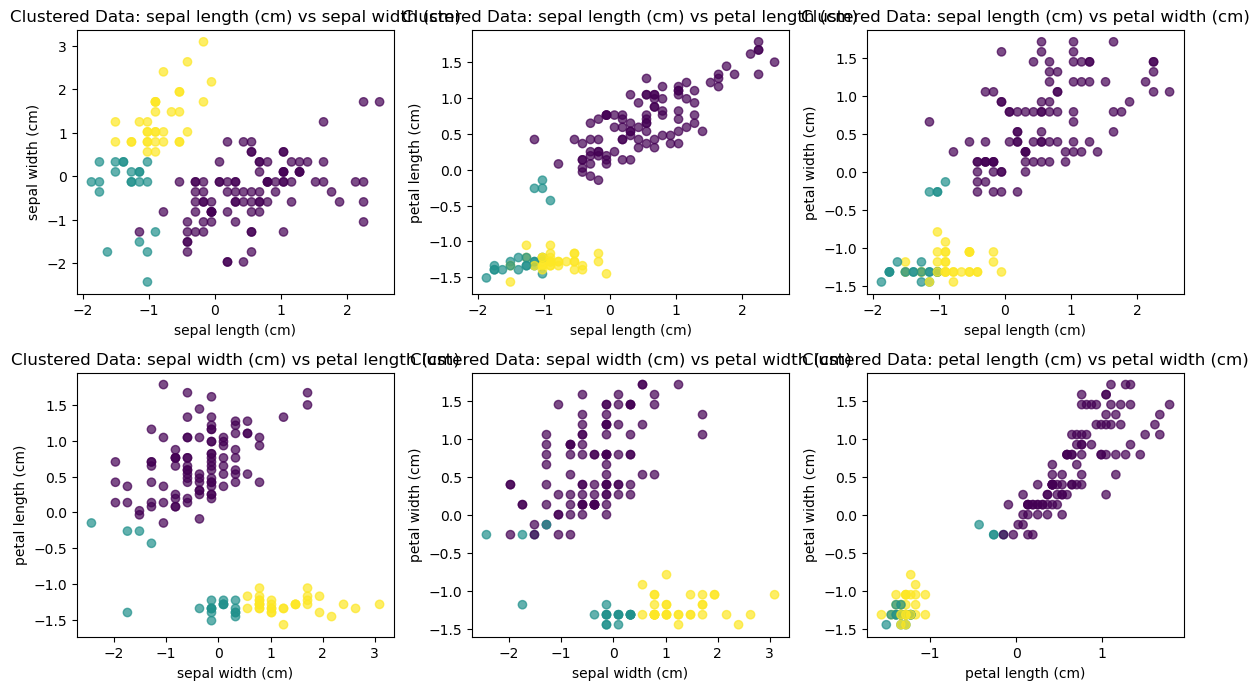

In [7]:
#Perform k-means clustering

iris_kmeans = KMeans(n_clusters=3, random_state=32)

clustered_iris_data = iris_kmeans.fit(scaled_iris_df)

# Add the cluster labels to the scaled DataFrame
scaled_iris_df['Cluster'] = iris_kmeans.labels_

# Use the updated DataFrame for plotting
plot_feature_pairs(scaled_iris_df, feature_names, 
                   color_labels=scaled_iris_df['Cluster'], 
                   title_prefix='Clustered Data: ')

We chose `k=3` for the number of clusters arbitrarily. However, in a real-world scenario, it is important to determine the optimal number of clusters using appropriate methods.

**Question**: What is one method commonly used to determine the optimal number of clusters in K-means clustering, and why is this method helpful?

One method that is commonly used to determine the optimal number of clusters in K-means cluster is the elbow method. This involves plotting the Within-Cluster Sum of Squares (WCSS) against the number of clusters.
- WCSS measures the total variance within the clusters, and is calculated as the sum of squared distances between each data point and the centroid of the assigned cluster.
- In this plot we are finding the point where increasing the number of k does not result in a significant reduction in the WCSS. 

This method is helpful as it balances the trade-off between too few clusters (high WCSS, underfitting) and too many clusters (low WCSS but overfitting overly complex models). It provides and visual way to intuitively determine the appropriate clusters by identifying the point of dimision returns in variance reduction.

#### **Question 5:** 
#### Bootstrapping 

Implement bootstrapping on the mean of Petal Width. Generate 10000 bootstrap samples, calculate the mean for each sample, and compute a 90% confidence interval.

In [33]:
# Set the random seed to ne 123 for reproducibility
np.random.seed(123)

# Create one sample and determine the mean
one_sample = iris_df.sample(n=32)
#one_sample
sample_mean_petal_width = one_sample['petal length (cm)'].mean()


# Initialize an empty list to store the bootstrap samples
bootstrap_samples = []

#Take 10,000 samples, and label them by replicate number
for i in range(10000):
    sample = one_sample.sample(frac=1, replace=True) #Sample with replacement
    sample = sample.assign(replicate=i) # Add replicate number
    bootstrap_samples.append(sample) # Store the sample

#Combine all bootstrap samples into one DataFrame
boot10000 = pd.concat(bootstrap_samples)
#print(boot10000)

#Calculate the mean petal width for each bootstrap sample (replicate)
boot_means = boot10000.groupby('replicate')['petal width (cm)'].mean().reset_index(name='mean_petal_width')
#boot_means

# Determine the 90% confidence interval bounds (5th and 95th percentiles)
lower_bound = boot_means["mean_petal_width"].quantile(0.05)
upper_bound = boot_means["mean_petal_width"].quantile(0.95)
mean_petal_width = boot_means['mean_petal_width'].mean()

# Display the result
print(f"Mean of Petal Width: {mean_petal_width}")
print(f"90% Confidence Interval of Mean Petal Width: ({lower_bound}, {upper_bound})")

Mean of Petal Width: 1.13810625
90% Confidence Interval of Mean Petal Width: (0.896875, 1.371875)


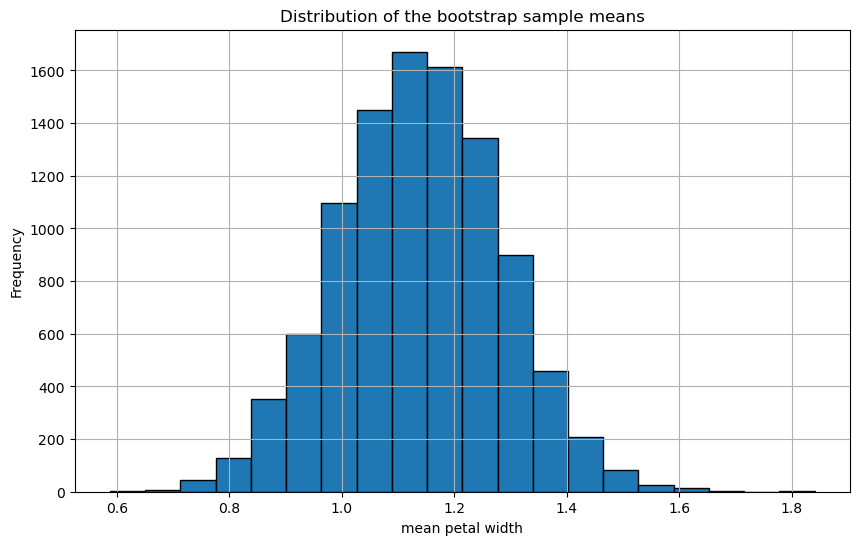

In [34]:
# Plot the histogram of the bootstrap distribution
plt.figure(figsize=(10, 6))
plt.hist(boot_means['mean_petal_width'], bins=20, edgecolor='black')

# Add titles and labels
plt.title('Distribution of the bootstrap sample means')
plt.xlabel('mean petal width')
plt.ylabel('Frequency')

# Show the plot
plt.grid(True)
plt.show()

**Question:**
- Why do we use bootstrapping in this context? What does it help us understand about the mean?

We use bootstrapping because we may have only one sample and lack of access to the full population. If we report a single sample estimate, reporting this may not adequately report our findings. Through boostrapping we can determine the variability of the mean, by resampling the available data to determine the plausible values for the mean and quanitfy our uncertainty of the range that is determined

**Question:**
- What is the purpose of calculating the confidence interval from the bootstrap samples? How does it help us interpret the variability of the estimate?

Through calculating the confidence interval, we can understand the uncertainty surrounding the estimate of the mean. The confidence internal shows the range of likely values for the population mean given the variability of the bootstrap samples. A narrow confidence interval indicates that the mean is stable and reliable estimate while a wide confidence interval suggests greather and less reliability.


**Question:**

- Reflect on the variability observed in the bootstrapped means and discuss whether the mean of the Petal Width appears to be a stable and reliable estimate based on the confidence interval and the spread of the bootstrapped means.

The Relative width is equal to the Confidence Interval (CI) Width divided by the Mean estimate. To calculate the interval the CI width, that would be taking the value of the upper bound and subtracting the lower bound values of the bootstrap and then dividing this by the mean value of the bootstrap. The calculation for our case would be: (1.371875-0.896875)/1.13810625. The resulting value from this calculation is 0.42. A value less than 0.5 suggests reasonable percision.Therefor our suggested mean is stable and reliable.

# Criteria


| **Criteria**                                           | **Complete**                                      | **Incomplete**                                    |
|--------------------------------------------------------|---------------------------------------------------|--------------------------------------------------|
| **Data Inspection**                                    | Data is thoroughly inspected for the number of variables, observations, and data types, and relevant insights are noted. | Data inspection is missing or lacks detail.         |
| **Data Visualization**                                 | Visualizations (e.g., scatter plots) are well-constructed and correctly interpreted to explore relationships between features and species. | Visualizations are poorly constructed or not correctly interpreted. |
| **Clustering Implementation**                           | K-Means clustering is correctly implemented, and cluster labels are appropriately assigned to the dataset.            | K-Means clustering is missing or incorrectly implemented. |
| **Bootstrapping Process**                              | Bootstrapping is correctly performed, and results are used to assess variable mean stability. | Bootstrapping is missing or incorrectly performed. |

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Note:

If you like, you may collaborate with others in the cohort. If you choose to do so, please indicate with whom you have worked with in your pull request by tagging their GitHub username. Separate submissions are required.

### Submission Parameters:
* Submission Due Date: `11:59 PM - 01/26/2025`
* The branch name for your repo should be: `assignment-3`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/LCR/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-4-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.
